# relevant clusters for barrier question: 
5 Port electrification drivers barriers
6 Romanian smart seaport transformation
11 EU legal framework microgrids islanding
17 MVDC protection and circuit breakers
18 DC zoning fault energy protection
12 Switchgear technology readiness and trends
10 DC microgrid EMT simulation
14 DC tools devices KPIs

##possible chunks per round: 
Round 1
Port-focused chunks

5 Port electrification drivers barriers
6 Romanian smart seaport transformation
Round 2
Legal/regulatory chunks

11 EU legal framework microgrids islanding
Round 3
Protection/technical chunks

17 MVDC protection and circuit breakers
18 DC zoning fault energy protection
12 Switchgear technology readiness and trends
10 DC microgrid EMT simulation

# rounds assigned clusters: 
A good pairing strategy for your task is:

Run A: 5 + 6
Port-focused
Run B: 5 + 11 or 6 + 11
Port + legal/regulatory
Run C: 5 + 17 or 6 + 17
Port + protection infrastructure
Run D: 5 + 18 or 6 + 18
Port + fault/protection barriers


# new direction of analysis:
- Marginal cluster coverage heatmap: communicates the additional barrier-cluster coverage obtained when one variant is added to another. Rows represent the baseline variant, columns represent the added variant, and each cell shows how many new clusters the column variant contributes beyond those already covered by the row variant. It therefore communicates the marginal value of adding a variant and directly supports assessing whether the added variant expands coverage enough to matter. [Does adding new variant really provide additional exploration of new clusters?]

Jaccard overlap heatmap: communicates the degree of similarity between the barrier-cluster sets covered by two variants. Each cell shows the Jaccard overlap between a pair of variants, computed as the ratio of shared clusters to total unique clusters across the pair. It therefore communicates how redundant or complementary two variants are, where higher values indicate stronger overlap and lower values indicate greater diversity of coverage. [ ]

- so while "marginal cluster coverage presents: additional number of clusters gained when a new variant is added", the "the jaccard overlap tells the degree of similarity between the barrier-clusters sets covered between the two caompared variants"

- Marginal cluster coverage between two variants, quantifies the additional number of clusters contributed when a variant is added to another. 
- Jaccard overlap between variants quantifies the degree of similarity between the cluster sets covered by two compared variants.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Resolve project paths robustly
ROOT = Path.cwd()

if (ROOT / "analysis").exists():
    BASE = ROOT
elif (ROOT / "rag_pipeline" / "roles-enhanced2" / "analysis").exists():
    BASE = ROOT / "rag_pipeline" / "roles-enhanced"
else:
    raise FileNotFoundError(
        "Could not locate roles-enhanced base folder. "
        "Run the notebook from either `rag_pipeline/roles-enhanced` "
        "or from the workspace root containing `rag_pipeline/roles-enhanced`."
    )

DATA_PATH = BASE / "analysis" / "context_barrier_mention_themes_hdbscan_named.csv"
CLUSTER_LOOKUP_PATH = BASE / "analysis" / "cluster-names-gpt5-human.csv"

print("BASE:", BASE)
print("DATA_PATH:", DATA_PATH)
print("CLUSTER_LOOKUP_PATH:", CLUSTER_LOOKUP_PATH)


BASE: c:\Users\FEEL\Downloads\images\rag_pipeline\roles-enhanced2
DATA_PATH: c:\Users\FEEL\Downloads\images\rag_pipeline\roles-enhanced2\analysis\context_barrier_mention_themes_hdbscan_named.csv
CLUSTER_LOOKUP_PATH: c:\Users\FEEL\Downloads\images\rag_pipeline\roles-enhanced2\analysis\cluster-names-gpt5-human.csv


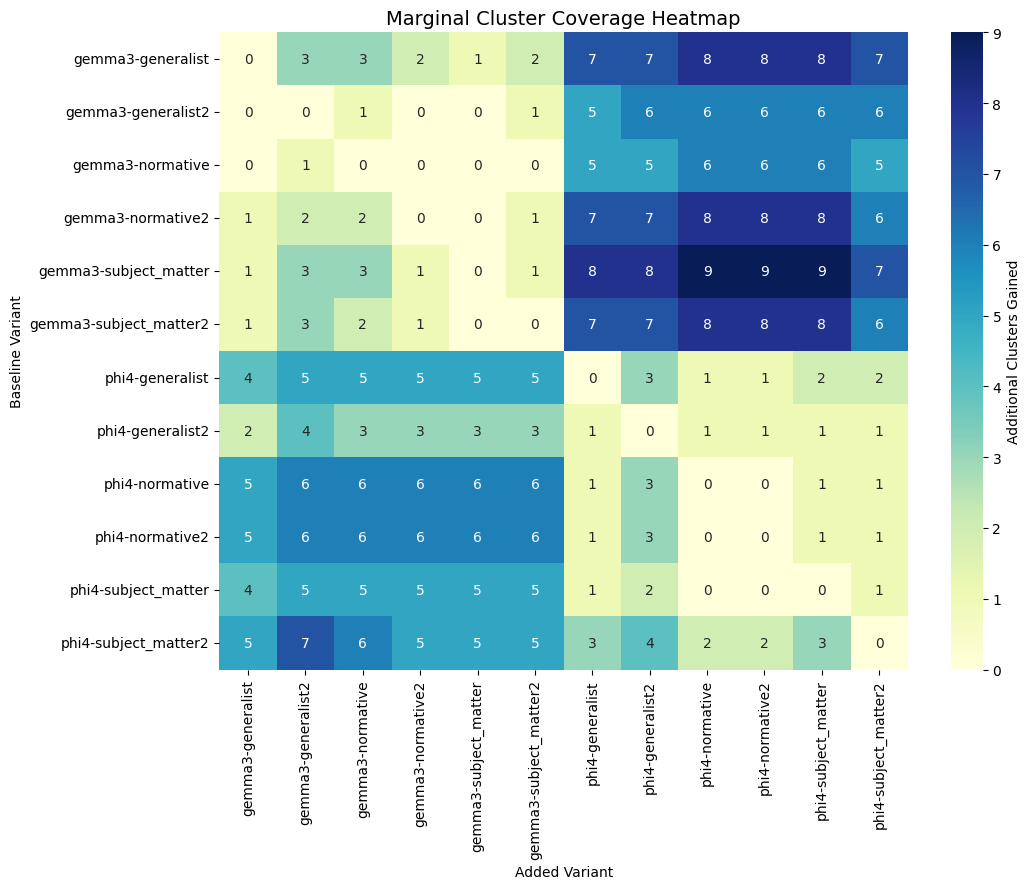

,gemma3-generalist,gemma3-generalist2,gemma3-normative,gemma3-normative2,gemma3-subject_matter,gemma3-subject_matter2,phi4-generalist,phi4-generalist2,phi4-normative,phi4-normative2,phi4-subject_matter,phi4-subject_matter2
gemma3-generalist,0.0,3.0,3.0,2.0,1.0,2.0,7.0,7.0,8.0,8.0,8.0,7.0
gemma3-generalist2,0.0,0.0,1.0,0.0,0.0,1.0,5.0,6.0,6.0,6.0,6.0,6.0
gemma3-normative,0.0,1.0,0.0,0.0,0.0,0.0,5.0,5.0,6.0,6.0,6.0,5.0
gemma3-normative2,1.0,2.0,2.0,0.0,0.0,1.0,7.0,7.0,8.0,8.0,8.0,6.0
gemma3-subject_matter,1.0,3.0,3.0,1.0,0.0,1.0,8.0,8.0,9.0,9.0,9.0,7.0
gemma3-subject_matter2,1.0,3.0,2.0,1.0,0.0,0.0,7.0,7.0,8.0,8.0,8.0,6.0
phi4-generalist,4.0,5.0,5.0,5.0,5.0,5.0,0.0,3.0,1.0,1.0,2.0,2.0
phi4-generalist2,2.0,4.0,3.0,3.0,3.0,3.0,1.0,0.0,1.0,1.0,1.0,1.0
phi4-normative,5.0,6.0,6.0,6.0,6.0,6.0,1.0,3.0,0.0,0.0,1.0,1.0
phi4-normative2,5.0,6.0,6.0,6.0,6.0,6.0,1.0,3.0,0.0,0.0,1.0,1.0


In [3]:
# Marginal cluster coverage heatmap

rows = pd.read_csv(DATA_PATH)
lookup = pd.read_csv(CLUSTER_LOOKUP_PATH)

lookup["cluster"] = pd.to_numeric(lookup["cluster"], errors="coerce")
lookup["human_labelled_clusters"] = lookup["human_labelled_clusters"].fillna("").astype(str).str.strip()
rename_map = {
    row["cluster"]: row["human_labelled_clusters"]
    for _, row in lookup.iterrows()
    if pd.notna(row["cluster"]) and row["human_labelled_clusters"]
}

rows["cluster"] = pd.to_numeric(rows["cluster"], errors="coerce")
rows.loc[rows["cluster"].isin(rename_map.keys()), "human_labelled_clusters"] = (
    rows.loc[rows["cluster"].isin(rename_map.keys()), "cluster"].map(rename_map)
)

rows = rows[rows["cluster"] >= 0].copy()
rows["variant_id"] = rows["variant_id"].astype(str).str.strip()
rows["human_labelled_clusters"] = rows["human_labelled_clusters"].astype(str).str.strip()

variant_sets = {
    variant: set(sub["human_labelled_clusters"])
    for variant, sub in rows.groupby("variant_id")
}

variants = sorted(variant_sets.keys())

marginal_gain = pd.DataFrame(index=variants, columns=variants, dtype=int)

for base in variants:
    for added in variants:
        base_set = variant_sets[base]
        added_set = variant_sets[added]
        gain = len(added_set - base_set)
        marginal_gain.loc[base, added] = gain

plt.figure(figsize=(11, 9))
sns.heatmap(
    marginal_gain,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    cbar_kws={"label": "Additional Clusters Gained"}
)
plt.title("Marginal Cluster Coverage Heatmap", fontsize=14)
plt.xlabel("Added Variant")
plt.ylabel("Baseline Variant")
plt.tight_layout()
plt.show()

marginal_gain


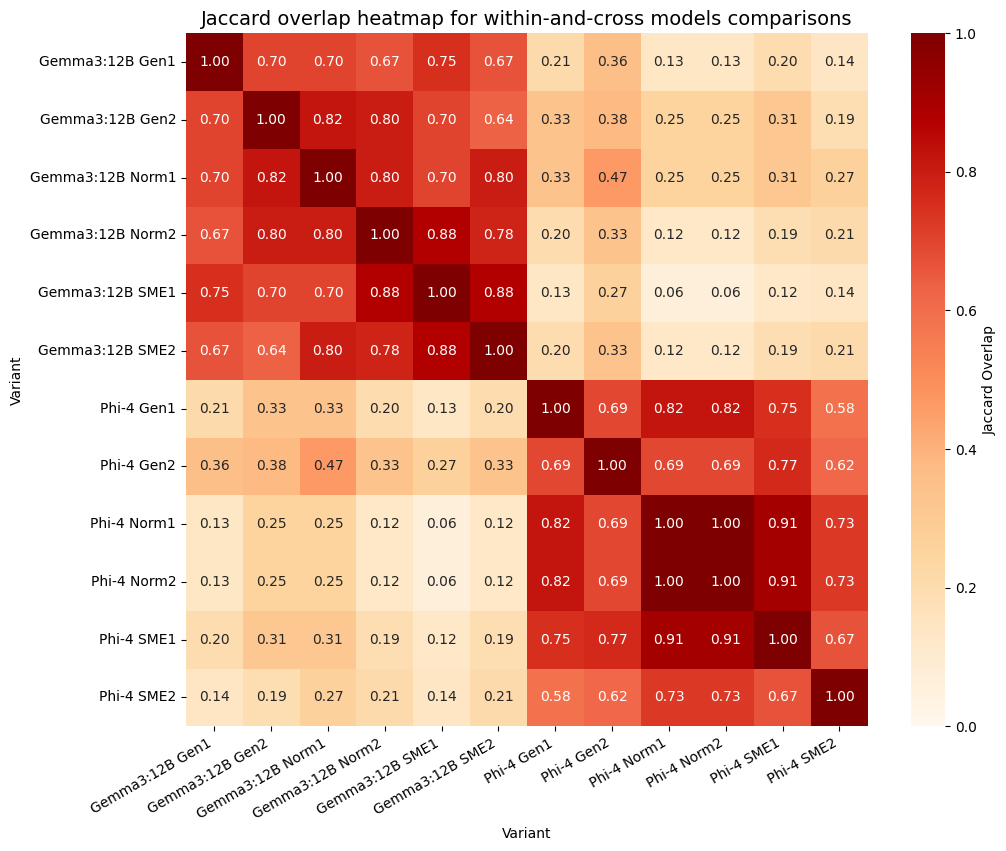

<Figure size 640x480 with 0 Axes>

In [16]:
# Jaccard overlap heatmap
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = Path("analysis/context_barrier_mention_themes_hdbscan_named.csv")
CLUSTER_LOOKUP_PATH = Path("analysis/cluster-names-gpt5-human.csv")

rows = pd.read_csv(DATA_PATH)
lookup = pd.read_csv(CLUSTER_LOOKUP_PATH)

lookup["cluster"] = pd.to_numeric(lookup["cluster"], errors="coerce")
lookup["human_labelled_clusters"] = lookup["human_labelled_clusters"].fillna("").astype(str).str.strip()
rename_map = {
    row["cluster"]: row["human_labelled_clusters"]
    for _, row in lookup.iterrows()
    if pd.notna(row["cluster"]) and row["human_labelled_clusters"]
}

rows["cluster"] = pd.to_numeric(rows["cluster"], errors="coerce")
rows.loc[rows["cluster"].isin(rename_map.keys()), "human_labelled_clusters"] = (
    rows.loc[rows["cluster"].isin(rename_map.keys()), "cluster"].map(rename_map)
)

rows = rows[rows["cluster"] >= 0].copy()
rows["variant_id"] = rows["variant_id"].astype(str).str.strip()
rows["human_labelled_clusters"] = rows["human_labelled_clusters"].astype(str).str.strip()

variant_sets = {
    variant: set(sub["human_labelled_clusters"])
    for variant, sub in rows.groupby("variant_id")
}

variants = sorted(variant_sets.keys())

jaccard = pd.DataFrame(index=variants, columns=variants, dtype=float)

for v1 in variants:
    for v2 in variants:
        s1 = variant_sets[v1]
        s2 = variant_sets[v2]
        union = s1 | s2
        inter = s1 & s2
        score = len(inter) / len(union) if union else 0.0
        jaccard.loc[v1, v2] = score

# add this here
variant_pretty = {
    "phi4-generalist": "Phi-4 Gen1",
    "phi4-generalist2": "Phi-4 Gen2",
    "phi4-normative": "Phi-4 Norm1",
    "phi4-normative2": "Phi-4 Norm2",
    "phi4-subject_matter": "Phi-4 SME1",
    "phi4-subject_matter2": "Phi-4 SME2",
    "gemma3-generalist": "Gemma3:12B Gen1",
    "gemma3-generalist2": "Gemma3:12B Gen2",
    "gemma3-normative": "Gemma3:12B Norm1",
    "gemma3-normative2": "Gemma3:12B Norm2",
    "gemma3-subject_matter": "Gemma3:12B SME1",
    "gemma3-subject_matter2": "Gemma3:12B SME2",
}

jaccard = jaccard.rename(index=variant_pretty, columns=variant_pretty)

plt.figure(figsize=(11, 9))
sns.heatmap(
    jaccard,
    annot=True,
    fmt=".2f",
    cmap="OrRd",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Jaccard Overlap"}
)
plt.title("Jaccard overlap heatmap for within-and-cross models comparisons", fontsize=14)
plt.xlabel("Variant")
plt.ylabel("Variant")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

# save figure
save_path = "analysis/jaccard_overlap_heatmap.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
plt.tight_layout()
# jaccard


computation: 
- use median pairwise JSD per variant
- then report the median of those medians across all variants
*Report: We assessed stability between runs using pairwise Jensen-Shannon divergence at barrier-cluster level distributions. Across all variants in the two model families, the median divergence remained low, implying generally stable generation across repeated runs. 
**We use Jensen Shannon Divergence to assess every variant's pairwise divergence between the runs. 
- We use median pairwise JSD to avoid occasional outliers iterations. 

In [18]:
# implementation of JSD
# cell1: Setup and imports
from pathlib import Path
import itertools
import numpy as np
import pandas as pd

# Resolve base path
ROOT = Path.cwd()

if (ROOT / "analysis").exists():
    BASE = ROOT
elif (ROOT / "rag_pipeline" / "roles-enhanced2" / "analysis").exists():
    BASE = ROOT / "rag_pipeline" / "roles-enhanced2"
elif (ROOT / "rag_pipeline" / "roles-enhanced" / "analysis").exists():
    BASE = ROOT / "rag_pipeline" / "roles-enhanced"
else:
    raise FileNotFoundError(
        "Could not locate roles-enhanced base folder."
    )

DATA_PATH = BASE / "analysis" / "context_barrier_mention_themes_hdbscan_named.csv"
LOOKUP_PATH = BASE / "analysis" / "cluster-names-gpt5-human.csv"

print("BASE:", BASE)
print("DATA_PATH:", DATA_PATH)
print("LOOKUP_PATH:", LOOKUP_PATH)


BASE: c:\Users\FEEL\Downloads\images\rag_pipeline\roles-enhanced2
DATA_PATH: c:\Users\FEEL\Downloads\images\rag_pipeline\roles-enhanced2\analysis\context_barrier_mention_themes_hdbscan_named.csv
LOOKUP_PATH: c:\Users\FEEL\Downloads\images\rag_pipeline\roles-enhanced2\analysis\cluster-names-gpt5-human.csv


In [19]:
# cell2: Load and prepare data
rows = pd.read_csv(DATA_PATH)
lookup = pd.read_csv(LOOKUP_PATH)

rows["cluster"] = pd.to_numeric(rows["cluster"], errors="coerce")
rows["iteration"] = pd.to_numeric(rows["iteration"], errors="coerce")
lookup["cluster"] = pd.to_numeric(lookup["cluster"], errors="coerce")

lookup["human_labelled_clusters"] = (
    lookup["human_labelled_clusters"].fillna("").astype(str).str.strip()
)

rename_map = {
    row["cluster"]: row["human_labelled_clusters"]
    for _, row in lookup.iterrows()
    if pd.notna(row["cluster"]) and row["human_labelled_clusters"]
}

rows.loc[rows["cluster"].isin(rename_map.keys()), "human_labelled_clusters"] = (
    rows.loc[rows["cluster"].isin(rename_map.keys()), "cluster"].map(rename_map)
)

rows = rows[rows["cluster"] >= 0].copy()
rows["variant_id"] = rows["variant_id"].astype(str).str.strip()
rows["role"] = rows["role"].astype(str).str.strip()
rows["base_model"] = rows["base_model"].astype(str).str.strip()
rows["human_labelled_clusters"] = rows["human_labelled_clusters"].astype(str).str.strip()

rows.head()


,row_id,base_model,variant_id,role,model,barrier_title,explanation,iteration,timestamp,truncated,...,theme_attempts,theme_error,theme_model,theme_temperature,cluster_text,cluster,cluster_prob,primary_category,secondary_category,human_labelled_clusters
0,phi4-generalist_00_b1,phi4,phi4-generalist,generalist,phi4-generalist-enh:latest,Interoperability Challenges,The lack of standardized protocols for integra...,0,20260505_121738,no,...,1,NaN,gpt-5.4-mini,0.2,Interoperability Challenges. The lack of stand...,13,1.000000,technical,general,Interoperability challenges with existing AC i...
1,phi4-generalist_00_b2,phi4,phi4-generalist,generalist,phi4-generalist-enh:latest,Grid Stability Concerns,Transitioning parts of the grid to DC could in...,0,20260505_121738,no,...,1,NaN,gpt-5.4-mini,0.2,Grid Stability Concerns. Transitioning parts o...,7,1.000000,technical,general,AC grid integration complexity
2,phi4-generalist_00_b3,phi4,phi4-generalist,generalist,phi4-generalist-enh:latest,Economic Viability Hurdles,The initial investment required for DC technol...,0,20260505_121738,no,...,1,NaN,gpt-5.4-mini,0.2,Economic Viability Hurdles. The initial invest...,9,1.000000,general,technical,High upfront transition costs
3,phi4-generalist_00_b4,phi4,phi4-generalist,generalist,phi4-generalist-enh:latest,Skill and Knowledge Gaps,There is a shortage of professionals trained i...,0,20260505_121738,no,...,1,NaN,gpt-5.4-mini,0.2,Skill and Knowledge Gaps. There is a shortage ...,2,1.000000,general,technical,Shortage in skilled workforce
4,phi4-generalist_00_b5,phi4,phi4-generalist,generalist,phi4-generalist-enh:latest,Public Perception and Acceptance,Limited public understanding or awareness of t...,0,20260505_121738,no,...,1,NaN,gpt-5.4-mini,0.2,Public Perception and Acceptance. Limited publ...,14,0.992688,policy,general,Public awareness and acceptance


In [20]:
# cell3: Build per-iteration cluster distributions
cluster_order = sorted(rows["human_labelled_clusters"].unique())
iter_counts = pd.crosstab(
    [rows["variant_id"], rows["base_model"], rows["role"], rows["iteration"]],
    rows["human_labelled_clusters"]
).reindex(columns=cluster_order, fill_value=0)

iter_dist = iter_counts.div(iter_counts.sum(axis=1), axis=0).fillna(0)
iter_dist.head()


human_labelled_clusters                            AC grid integration complexity  \
variant_id        base_model role       iteration                                   
gemma3-generalist gemma3:12b generalist 0                                     0.0   
                                        1                                     0.0   
                                        2                                     0.0   
                                        3                                     0.0   
                                        4                                     0.0   

human_labelled_clusters                            Cybersecurity vulnerabilities in DC microgrids  \
variant_id        base_model role       iteration                                                   
gemma3-generalist gemma3:12b generalist 0                                                     0.2   
                                        1                                                     0.0   
                                        2                                                     0.0   
                                        3                                                     0.2   
                                        4                                                     0.0   

human_labelled_clusters                            DC component cost and availability  \
variant_id        base_model role       iteration                                       
gemma3-generalist gemma3:12b generalist 0                                         0.2   
                                        1                                         0.0   
                                        2                                         0.0   
                                        3                                         0.2   
                                        4                                         0.0   

human_labelled_clusters                            DC interoperability standardization and certification gap  \
variant_id        base_model role       iteration                                                              
gemma3-generalist gemma3:12b generalist 0                                                   0.200000           
                                        1                                                   0.250000           
                                        2                                                   0.333333           
                                        3                                                   0.200000           
                                        4                                                   0.200000           

human_labelled_clusters                            DC market readiness challenges  \
variant_id        base_model role       iteration                                   
gemma3-generalist gemma3:12b generalist 0                                     0.0   
                                        1                                     0.0   
                                        2                                     0.0   
                                        3                                     0.0   
                                        4                                     0.0   

human_labelled_clusters                            DC standards fragmented  \
variant_id        base_model role       iteration                            
gemma3-generalist gemma3:12b generalist 0                              0.0   
                                        1                              0.0   
                                        2                              0.0   
                                        3                              0.0   
                                        4                              0.0   

human_labelled_clusters                            DC supply chain constraints  \
variant_id        base_model role       iteration             

In [21]:
# cell4: Jensen-Shannon divergence
def jsd(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = p / p.sum()
    q = q / q.sum()

    m = 0.5 * (p + q)

    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / (b[mask] + eps)))

    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


In [25]:
# cell5: Compute pairwise JSD across iterations within each variant
pair_rows = []

for variant_id, sub in iter_dist.groupby(level="variant_id"):
    sub = sub.reset_index()
    meta_family = sub["base_model"].iloc[0]
    meta_role = sub["role"].iloc[0]

    iteration_rows = []
    for _, row in sub.iterrows():
        iteration_rows.append({
            "iteration": int(row["iteration"]),
            "dist": row[cluster_order].values.astype(float)
        })

    for a, b in itertools.combinations(iteration_rows, 2):
        score = jsd(a["dist"], b["dist"])
        pair_rows.append({
            "variant_id": variant_id,
            "base_model": meta_family,
            "role": meta_role,
            "iteration_a": a["iteration"],
            "iteration_b": b["iteration"],
            "jsd": score,
        })

pairwise_jsd = pd.DataFrame(pair_rows)
pairwise_jsd.head(5)


,variant_id,base_model,role,iteration_a,iteration_b,jsd
0,gemma3-generalist,gemma3:12b,generalist,0,1,3.310237e-01
1,gemma3-generalist,gemma3:12b,generalist,0,2,2.364528e-01
2,gemma3-generalist,gemma3:12b,generalist,0,3,-7.213476e-12
3,gemma3-generalist,gemma3:12b,generalist,0,4,4.000000e-01
4,gemma3-generalist,gemma3:12b,generalist,0,5,4.000000e-01


In [49]:
# cell6: Variant-level robust stability summary: median pairwise JSD per variant
variant_stability = (
    pairwise_jsd.groupby(["variant_id", "base_model", "role"])["jsd"]
    .agg(
        median_jsd="median",
        std_jsd="std",
        q1_jsd=lambda x: x.quantile(0.25),
        q3_jsd=lambda x: x.quantile(0.75),
    )
    .reset_index()
    .sort_values(["base_model", "role", "variant_id"])
    .reset_index(drop=True)
)

# Pretty labels
variant_pretty = {
    "phi4-generalist": "Phi-4 Gen1",
    "phi4-generalist2": "Phi-4 Gen2",
    "phi4-normative": "Phi-4 Norm1",
    "phi4-normative2": "Phi-4 Norm2",
    "phi4-subject_matter": "Phi-4 SME1",
    "phi4-subject_matter2": "Phi-4 SME2",
    "gemma3-generalist": "Gemma3:12B Gen1",
    "gemma3-generalist2": "Gemma3:12B Gen2",
    "gemma3-normative": "Gemma3:12B Norm1",
    "gemma3-normative2": "Gemma3:12B Norm2",
    "gemma3-subject_matter": "Gemma3:12B SME1",
    "gemma3-subject_matter2": "Gemma3:12B SME2",
}

family_pretty = {
    "phi4": "Phi-4",
    "gemma3:12b": "Gemma3:12B",
}

role_pretty = {
    "generalist": "Generalist",
    "normative": "Normative",
    "subject_matter": "Subject-matter",
}

stability_table = variant_stability.copy()

stability_table["variant_id"] = stability_table["variant_id"].map(variant_pretty).fillna(stability_table["variant_id"])
stability_table["base_model"] = stability_table["base_model"].map(family_pretty).fillna(stability_table["base_model"])
stability_table["role"] = stability_table["role"].map(role_pretty).fillna(stability_table["role"])

stability_table = stability_table.rename(columns={
    "variant_id": "Variant",
    "base_model": "Family",
    "role": "Role",
    "median_jsd": "Median Pairwise JSD",
    "std_jsd": "Std JSD",
    "q1_jsd": "Q1 JSD",
    "q3_jsd": "Q3 JSD",
})

stability_table["Median Pairwise JSD"] = stability_table["Median Pairwise JSD"].round(4)
stability_table["Std JSD"] = stability_table["Std JSD"].round(4)
stability_table["Q1 JSD"] = stability_table["Q1 JSD"].round(4)
stability_table["Q3 JSD"] = stability_table["Q3 JSD"].round(4)

stability_table["IQR"] = stability_table.apply(
    lambda r: f"[{r['Q1 JSD']:.4f}, {r['Q3 JSD']:.4f}]",
    axis=1
)

stability_table["IQR Value"] = (
    stability_table["Q3 JSD"] - stability_table["Q1 JSD"]
).round(4)

stability_table = stability_table[[
    "Family",
    "Role",
    "Variant",
    "Median Pairwise JSD",
    "Std JSD",
    #"IQR",
    "IQR Value",
]]

stability_table


,Family,Role,Variant,Median Pairwise JSD,Std JSD,IQR Value
0,Gemma3:12B,Generalist,Gemma3:12B Gen1,0.2365,0.1424,0.2230
1,Gemma3:12B,Generalist,Gemma3:12B Gen2,0.3310,0.1708,0.2230
2,Gemma3:12B,Normative,Gemma3:12B Norm1,0.2000,0.2240,0.4000
3,Gemma3:12B,Normative,Gemma3:12B Norm2,0.2000,0.1313,0.0000
4,Gemma3:12B,Subject-matter,Gemma3:12B SME1,0.2000,0.1820,0.2920
5,Gemma3:12B,Subject-matter,Gemma3:12B SME2,0.3310,0.1771,0.3245
6,Phi-4,Generalist,Phi-4 Gen1,0.4000,0.1830,0.2000
7,Phi-4,Generalist,Phi-4 Gen2,0.5540,0.2013,0.2000
8,Phi-4,Normative,Phi-4 Norm1,0.4000,0.1860,0.2000
9,Phi-4,Normative,Phi-4 Norm2,0.4000,0.1868,0.4000


In [50]:
# cell7: Robust stability summary per model family
family_stability = (
    variant_stability.groupby("base_model")["median_jsd"]
    .agg(
        median_of_variant_medians="median",
        iqr_low=lambda x: x.quantile(0.25),
        iqr_high=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

family_pretty = {
    "phi4": "Phi-4",
    "gemma3:12b": "Gemma3:12B",
}

family_stability["base_model"] = family_stability["base_model"].map(family_pretty).fillna(family_stability["base_model"])

family_stability = family_stability.rename(columns={
    "base_model": "Family",
    "median_of_variant_medians": "Median of Variant Median JSDs",
    "iqr_low": "IQR Low",
    "iqr_high": "IQR High",
})

family_stability["Median of Variant Median JSDs"] = family_stability["Median of Variant Median JSDs"].round(4)
family_stability["IQR Low"] = family_stability["IQR Low"].round(4)
family_stability["IQR High"] = family_stability["IQR High"].round(4)

family_stability


,Family,Median of Variant Median JSDs,IQR Low,IQR High
0,Gemma3:12B,0.2182,0.2,0.3074
1,Phi-4,0.4000,0.4,0.4000


In [51]:
# LaTeX export
OUT_PATH = BASE / "analysis" / "variant_stability_table.tex"

latex_str = stability_table.to_latex(
    index=False,
    escape=True,
    float_format="%.4f",
    caption="Variant-level stability based on pairwise Jensen-Shannon divergence across iterations.",
    label="tab:variant_stability_jsd",
)

OUT_PATH.write_text(latex_str, encoding="utf-8")
print(f"Saved LaTeX table to: {OUT_PATH}")



Saved LaTeX table to: c:\Users\FEEL\Downloads\images\rag_pipeline\roles-enhanced2\analysis\variant_stability_table.tex
